<a href="https://colab.research.google.com/github/2estherblaise-max/ECON3916-Statical-Machine-Learning./blob/main/LAB18ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!pip install kagglehub pandas numpy scikit-learn matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("Setup complete ✓")

Setup complete ✓


In [29]:
import kagglehub, os

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['Class'].value_counts()}")
print(f"\nFraud rate: {df['Class'].mean():.4%}")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


In [30]:
print("First 5 rows:")
print(df.head())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nTransaction amount stats:")
print(df['Amount'].describe())

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       

In [31]:
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} transactions ({y_train.sum()} frauds)")
print(f"Test set:     {X_test.shape[0]:,} transactions ({y_test.sum()} frauds)")

Training set: 227,845 transactions (394 frauds)
Test set:     56,962 transactions (98 frauds)


In [32]:
naive_predictions = np.zeros(len(y_test))
naive_accuracy = (naive_predictions == y_test).mean()

print(f"Naïve baseline accuracy: {naive_accuracy:.4%}")
print(f"Naïve baseline recall (fraud class): {recall_score(y_test, naive_predictions):.4%}")
print(f"\n→ 99.83% accuracy, 0% recall. The accuracy paradox in action.")

Naïve baseline accuracy: 99.8280%
Naïve baseline recall (fraud class): 0.0000%

→ 99.83% accuracy, 0% recall. The accuracy paradox in action.


In [33]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_prob = log_reg.predict_proba(X_test)[:, 1]
y_pred = log_reg.predict(X_test)

print(f"Model accuracy: {(y_pred == y_test).mean():.4%}")

Model accuracy: 99.9157%


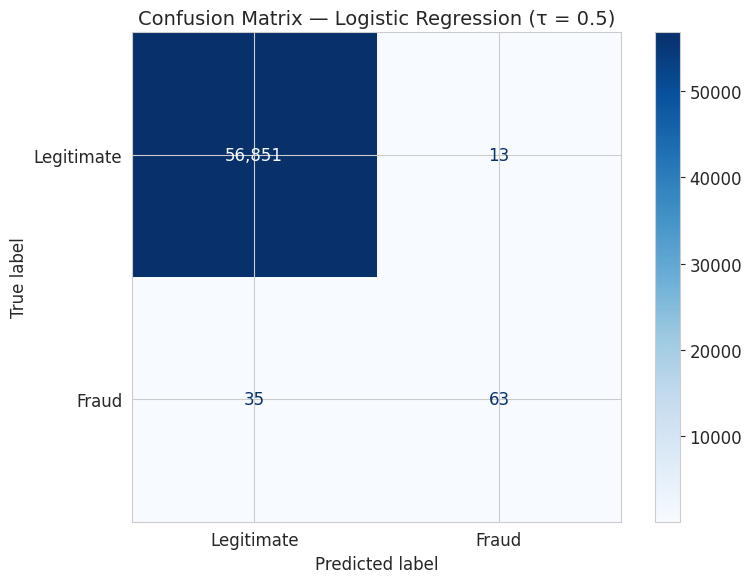

True Positives (fraud caught):     63
False Negatives (fraud missed):    35
False Positives (legit blocked):   13
True Negatives (legit approved):   56,851


In [34]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (fraud caught):     {tp}")
print(f"False Negatives (fraud missed):    {fn}")
print(f"False Positives (legit blocked):   {fp}")
print(f"True Negatives (legit approved):   {tn:,}")

In [35]:
print("Classification Report (τ = 0.5):")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

Classification Report (τ = 0.5):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



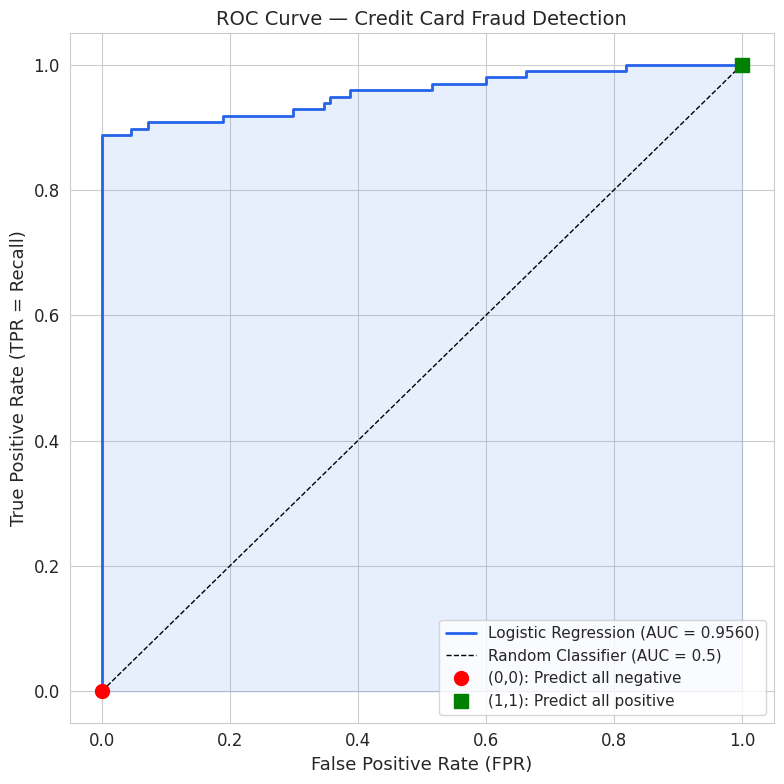

AUC = 0.9560


In [36]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='#2563eb', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')
ax.plot(0, 0, 'ro', markersize=10, label='(0,0): Predict all negative')
ax.plot(1, 1, 'gs', markersize=10, label='(1,1): Predict all positive')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=13)
ax.set_title('ROC Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

print(f"AUC = {auc_score:.4f}")

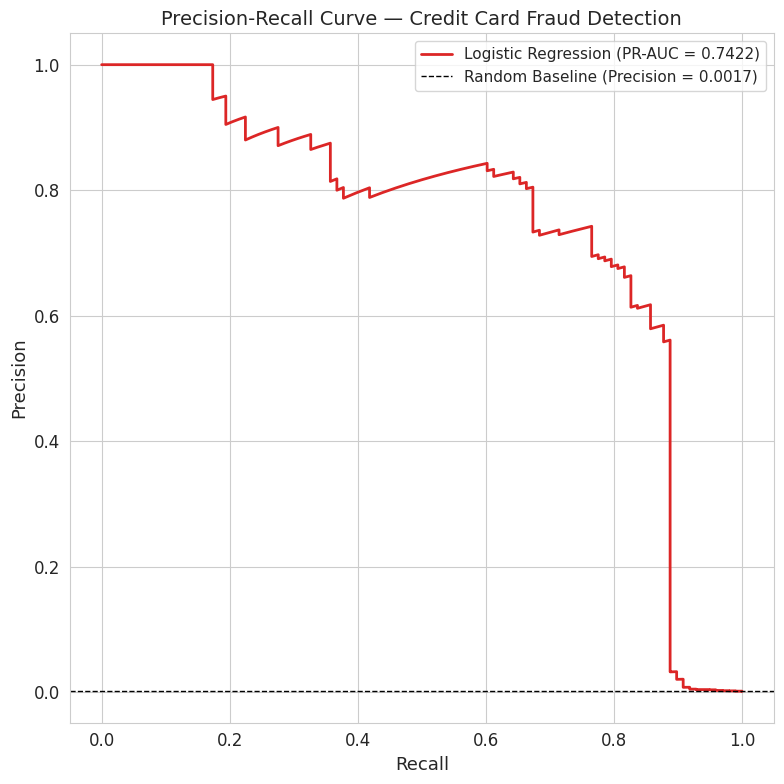

PR-AUC = 0.7422


In [37]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_vals, precision_vals)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(recall_vals, precision_vals, color='#dc2626', linewidth=2,
        label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')
baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1,
           label=f'Random Baseline (Precision = {baseline:.4f})')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

print(f"PR-AUC = {pr_auc:.4f}")

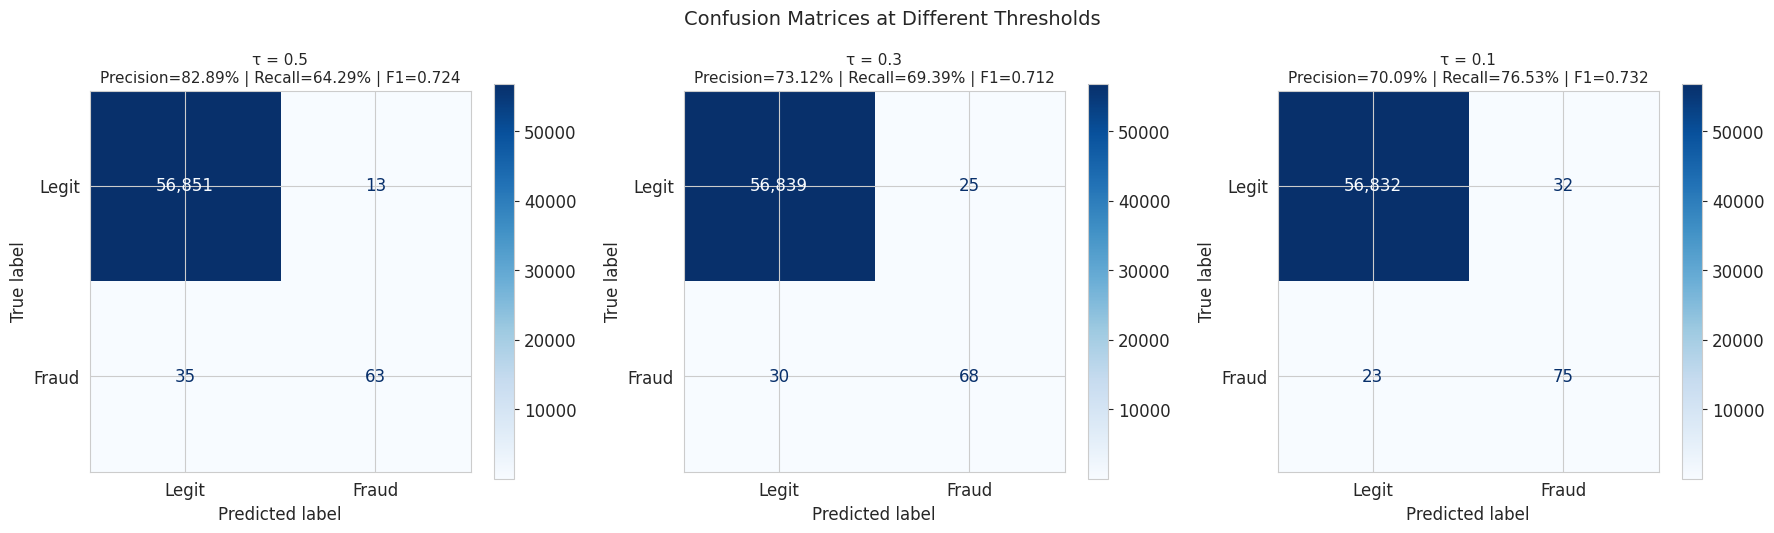

In [38]:
thresholds_to_test = [0.5, 0.3, 0.1]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, tau in enumerate(thresholds_to_test):
    y_pred_tau = (y_prob >= tau).astype(int)
    cm_tau = confusion_matrix(y_test, y_pred_tau)
    prec = precision_score(y_test, y_pred_tau, zero_division=0)
    rec = recall_score(y_test, y_pred_tau)
    f1 = f1_score(y_test, y_pred_tau)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_tau, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], cmap='Blues', values_format=',')
    axes[i].set_title(f'τ = {tau}\nPrecision={prec:.2%} | Recall={rec:.2%} | F1={f1:.3f}', fontsize=11)

plt.suptitle('Confusion Matrices at Different Thresholds', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

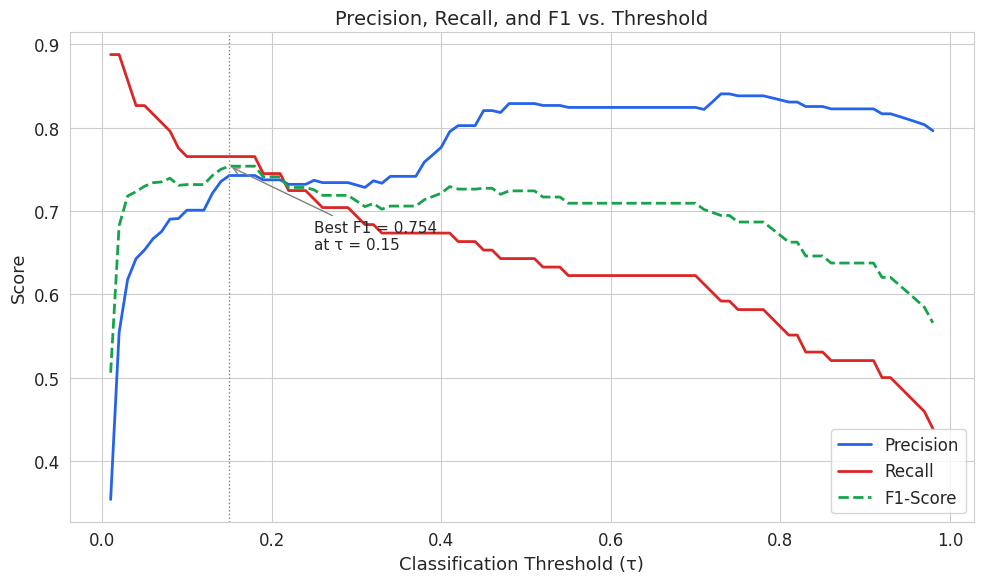


Optimal threshold for F1: τ = 0.15 (F1 = 0.754)


In [39]:
f1_scores, precision_scores, recall_scores = [], [], []
threshold_range = np.arange(0.01, 0.99, 0.01)

for tau in threshold_range:
    y_pred_tau = (y_prob >= tau).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_tau, zero_division=0))
    precision_scores.append(precision_score(y_test, y_pred_tau, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_tau, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_range, precision_scores, label='Precision', color='#2563eb', linewidth=2)
ax.plot(threshold_range, recall_scores, label='Recall', color='#dc2626', linewidth=2)
ax.plot(threshold_range, f1_scores, label='F1-Score', color='#16a34a', linewidth=2, linestyle='--')

best_tau = threshold_range[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
ax.axvline(x=best_tau, color='gray', linestyle=':', linewidth=1)
ax.annotate(f'Best F1 = {best_f1:.3f}\nat τ = {best_tau:.2f}',
            xy=(best_tau, best_f1), xytext=(best_tau + 0.1, best_f1 - 0.1),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_xlabel('Classification Threshold (τ)', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision, Recall, and F1 vs. Threshold', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold for F1: τ = {best_tau:.2f} (F1 = {best_f1:.3f})")

In [40]:
max_investigations = 500

for tau in np.arange(0.01, 0.99, 0.01):
    n_flagged = (y_prob >= tau).sum()
    if n_flagged <= max_investigations:
        y_pred_capacity = (y_prob >= tau).astype(int)
        rec = recall_score(y_test, y_pred_capacity)
        prec = precision_score(y_test, y_pred_capacity, zero_division=0)
        print(f"τ = {tau:.2f} → {n_flagged} flagged | Recall = {rec:.2%} | Precision = {prec:.2%}")
        break

τ = 0.01 → 246 flagged | Recall = 88.78% | Precision = 35.37%
